In [41]:
import pandas as pd
import sys
import os

# Add the parent directory to sys.path so src can be imported
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import src.utils as utils

In [42]:
file_path = r"..\data\processed\corpus_date_formatted.xlsx"
corpus = pd.read_excel(file_path, engine='openpyxl')

In [43]:
# Aplicar limpieza al corpus
corpus = utils.aplicar_funcion_limpieza(corpus)

path_processed = r"..\data\processed"

corpus.to_excel(os.path.join(path_processed, 'corpus_cleaned.xlsx'), index=False)


In [53]:
# Crear chunks solapados
chunks_df = utils.crear_chunks(corpus, columna_texto='Texto_limpio', tamaño=150, solapamiento=20, umbral_minimo=100)

# Ver primeros resultados
print(chunks_df.head())


   id_doc                 autor_doc  fecha_doc     diario_doc  \
0       1         Gonzalo Hernández 2018-01-01  El Espectador   
1       1         Gonzalo Hernández 2018-01-01  El Espectador   
2       1         Gonzalo Hernández 2018-01-01  El Espectador   
3       1         Gonzalo Hernández 2018-01-01  El Espectador   
4       2  Eduardo Barajas Sandoval 2018-01-01  El Espectador   

                 titulo_doc  chunk_id  \
0  Fajardo: para nada tibio         0   
1  Fajardo: para nada tibio         1   
2  Fajardo: para nada tibio         2   
3  Fajardo: para nada tibio         3   
4        Macedonia de Norte         0   

                                         texto_chunk  
0  La Coalición Colombia Partido Alianza Verde, P...  
1  al mismo tiempo lo exponen, en ciertas ocasion...  
2  los acuerdos con las Farc. Anunció que no prom...  
3  moratoria en la explotación tipo fracking. Y f...  
4  Las interpretaciones de la historia sirven com...  


In [54]:
cols_str = ["titulo_doc", "autor_doc", "diario_doc"]
chunks_df[cols_str] = chunks_df[cols_str].astype(str)

In [55]:
len(chunks_df)

62651

In [56]:
len(corpus['Texto_limpio'][0].split())

534

In [57]:
# Exportar chunks a Excel 
chunks_excel_path = r"..\data\processed\chunks.xlsx"
chunks_df.to_excel(chunks_excel_path, index=False, engine="openpyxl")

chunks_parquet_path = r"..\data\processed\chunks.parquet"
chunks_df.to_parquet(chunks_parquet_path, index=False, engine="pyarrow")

print("Chunks exportados a Excel y Parquet.")


Chunks exportados a Excel y Parquet.


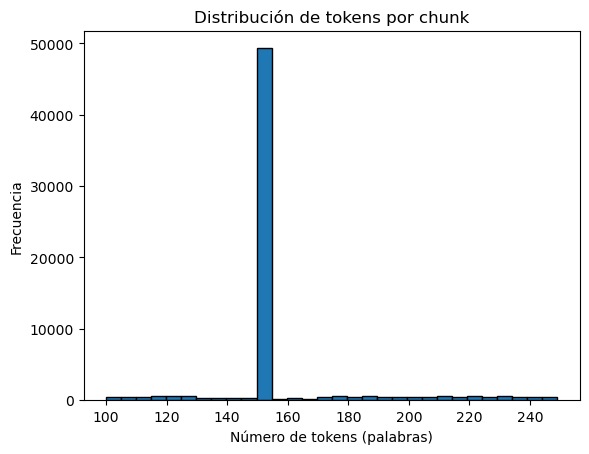

In [59]:
# Contar tokens como número de palabras
palabras_chunk = chunks_df["texto_chunk"].apply(lambda x: len(x.split()))

# Graficar histograma
import matplotlib.pyplot as plt

plt.hist(palabras_chunk, bins=30, edgecolor="black")
plt.xlabel("Número de tokens (palabras)")
plt.ylabel("Frecuencia")
plt.title("Distribución de tokens por chunk")
plt.show()


In [52]:
palabras_chunk.describe()

count    62651.000000
mean       155.990359
std         23.758940
min        100.000000
25%        150.000000
50%        150.000000
75%        150.000000
max        249.000000
Name: texto_chunk, dtype: float64